# U25 — Reinforcement Learning (finish): Deep RL Lab

### Real-world brief: a self-learning controller for an industrial furnace

An industrial furnace must be held at a **70 °C setpoint** by choosing a heater level every step — trading temperature error against energy cost. The catch: temperature is **continuous**, so the lookup tables from Part 1 don't fit. This is exactly where **deep RL** comes in. You'll build three approaches **from scratch in NumPy** (no deep-learning framework needed): **linear function approximation**, a **Deep Q-Network** (a small neural net with experience replay + a target network), and a **policy gradient** (REINFORCE) — and watch each learn to control the furnace.

**Resource provided:** `furnace_config.csv` — the furnace's physical parameters (edit it to change the problem). Only numpy + matplotlib required.

_Phase G — Reinforcement Learning._

#objectives

See why tabular RL fails on continuous state

Approximate Q with features + weights (linear function approximation)

Build a DQN from scratch: neural net + experience replay + target network

Implement a policy gradient (REINFORCE) and contrast it with value-based RL

Evaluate learned controllers against engineered baselines

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter. Training cells take a few seconds each.

In [2]:
# === SETUP: build the furnace config if missing ===
import os
import pandas as pd


def build_furnace(path="furnace_config.csv", verbose=False):
    """Physical configuration for the industrial-furnace control environment used in the
    deep-RL lab (U25 Part 2). Provided as an editable CSV 'resource' — change a value and the
    control problem changes (e.g. raise energy_weight to make heating more costly).

    The agent must hold the furnace at the setpoint by choosing a heater level each step,
    trading temperature error against energy use — a continuous-state control task where a
    lookup table won't fit, so we need function approximation / deep RL.
    """
    rows = [
        ("ambient_temp", 20.0, "deg C the furnace cools toward when off"),
        ("setpoint", 70.0, "target temperature to hold"),
        ("cooling_coeff", 0.10, "passive heat-loss rate per step"),
        ("power_off", 0.0, "heat added by action 0 (off)"),
        ("power_low", 5.0, "heat added by action 1 (holds setpoint at equilibrium)"),
        ("power_high", 8.0, "heat added by action 2 (heats up fast)"),
        ("energy_weight", 0.02, "penalty per unit of heater power in the reward"),
        ("noise_std", 0.30, "random disturbance on the temperature each step"),
        ("episode_steps", 60, "steps per control episode"),
    ]
    df = pd.DataFrame(rows, columns=["parameter", "value", "description"])
    df.to_csv(path, index=False)
    if verbose:
        print(df.to_string(index=False))
    return df

if not os.path.exists('furnace_config.csv'):
    build_furnace(); print('Generated furnace_config.csv')
else:
    print('Found furnace_config.csv')

Found furnace_config.csv


In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import deque
cfg = pd.read_csv('furnace_config.csv').set_index('parameter')['value'].to_dict()
print('furnace configuration:')
for k, v in cfg.items(): print(f'  {k:15s} = {v}')

furnace configuration:
  ambient_temp    = 20.0
  setpoint        = 70.0
  cooling_coeff   = 0.1
  power_off       = 0.0
  power_low       = 5.0
  power_high      = 8.0
  energy_weight   = 0.02
  noise_std       = 0.3
  episode_steps   = 60.0


#1. The environment & baselines

In [4]:
# -----------------------------------------------------------
# 🔹 1A. THE FURNACE: a continuous-state control MDP
# state = [normalised temp, normalised error];  actions = {0:off, 1:low, 2:high}
# -----------------------------------------------------------
class Furnace:
    def __init__(self, cfg, seed=0):
        self.c = cfg; self.power = [cfg['power_off'], cfg['power_low'], cfg['power_high']]
        self.rng = np.random.default_rng(seed)
    def reset(self):
        self.t = 0; self.temp = self.rng.uniform(25, 55); return self._state()
    def _state(self):
        return np.array([(self.temp - self.c['ambient_temp']) / 80.0,
                         (self.temp - self.c['setpoint']) / 40.0])
    def step(self, a):
        p = self.power[a]
        self.temp += p - self.c['cooling_coeff'] * (self.temp - self.c['ambient_temp'])
        self.temp += self.rng.normal(0, self.c['noise_std'])
        self.t += 1
        reward = -((self.temp - self.c['setpoint'])**2) / 100.0 - self.c['energy_weight'] * p
        done = self.t >= int(self.c['episode_steps'])
        return self._state(), reward, done

NA = 3   # number of actions
def evaluate(act_fn, episodes=40, seed=99):
    env = Furnace(cfg, seed); tot = []
    for _ in range(episodes):
        s = env.reset(); R = 0; done = False
        while not done: s, r, done = env.step(act_fn(s)); R += r
        tot.append(R)
    return np.mean(tot)

def temp_of(s): return s[0] * 80 + 20   # decode temperature from state
print('environment ready. State is continuous -> a lookup table cannot index it.')

environment ready. State is continuous -> a lookup table cannot index it.


In [6]:
# -----------------------------------------------------------
# 🔹 1B. BASELINE controllers to beat
# -----------------------------------------------------------
def always_high(s): return 2
def always_low(s):  return 1
def hand_tuned(s):                       # a sensible engineered thermostat
    t = temp_of(s)
    return 2 if t < 68 else (1 if t < 72 else 0)

for name, fn in [('always-high', always_high), ('always-low', always_low), ('hand-tuned', hand_tuned)]:
    print(f'{name:12s} mean return = {evaluate(fn):7.1f}')
print('\nThe hand-tuned controller is the bar to beat (higher = closer to setpoint, less energy).')

always-high  mean return =  -382.3
always-low   mean return =   -47.9
hand-tuned   mean return =   -21.2

The hand-tuned controller is the bar to beat (higher = closer to setpoint, less energy).


#### 🧪 EXERCISE 1 — Visualise a baseline
1. Run one 60-step episode under `hand_tuned`, recording the temperature each step, and plot it against the setpoint (70). (Use a fresh `Furnace(cfg)`, step manually, collect `temp_of(s)`.)
2. In a comment, note why temperature being *continuous* means the Part-1 tabular methods can't be applied directly.

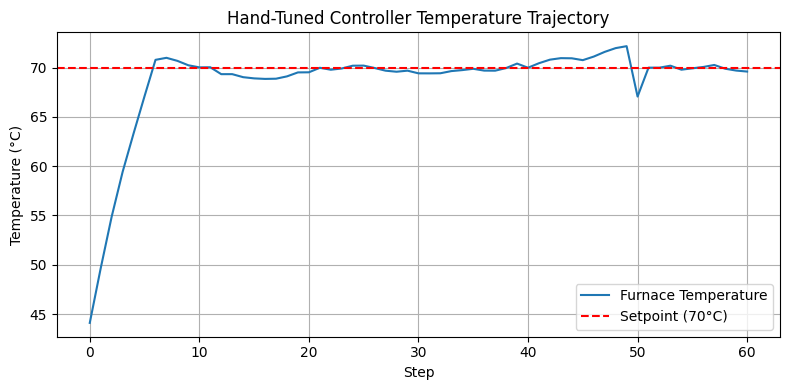

In [7]:
# 1. plot a temperature trajectory under the hand-tuned controller
env = Furnace(cfg)
s = env.reset()
temps = [temp_of(s)]
done = False

while not done:
    action = hand_tuned(s)
    s, reward, done = env.step(action)
    temps.append(temp_of(s))

plt.figure(figsize=(8, 4))
plt.plot(temps, label='Furnace Temperature')
plt.axhline(cfg['setpoint'], color='red', linestyle='--', label='Setpoint (70°C)')
plt.xlabel('Step')
plt.ylabel('Temperature (°C)')
plt.title('Hand-Tuned Controller Temperature Trajectory')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. why continuous state breaks tabular RL:
# Tabular RL methods, like Q-learning with a Q-table, require discretizing the state space.
# When the state space is continuous, like temperature in this furnace example, it's impossible
# to create an exhaustive table that covers every possible state. Even with fine-grained
# discretization, the number of states would become astronomically large, leading to the
# "curse of dimensionality." Furthermore, the agent wouldn't be able to generalize learning
# from one observed temperature to a very slightly different, unobserved temperature, making
# learning inefficient or impossible.

#2. Function approximation (linear)

In [8]:
# -----------------------------------------------------------
# 🔹 2A. Why not just discretise? The curse of dimensionality
# -----------------------------------------------------------
for bins in [10, 50, 100]:
    print(f'{bins} bins per dim -> {bins**2:>6,} states for 2 dims, {bins**4:>12,} for 4 dims')
print('Fine grids explode and still cannot generalise between nearby states. Instead: approximate Q.')

10 bins per dim ->    100 states for 2 dims,       10,000 for 4 dims
50 bins per dim ->  2,500 states for 2 dims,    6,250,000 for 4 dims
100 bins per dim -> 10,000 states for 2 dims,  100,000,000 for 4 dims
Fine grids explode and still cannot generalise between nearby states. Instead: approximate Q.


In [10]:
# -----------------------------------------------------------
# 🔹 2B. RBF features + semi-gradient Q-learning: Q(s,a) = w_a . phi(s)
# -----------------------------------------------------------
CENTERS = np.array([[c1, c2] for c1 in np.linspace(0, 1, 7) for c2 in np.linspace(-1.2, 1, 7)])
SIG = 0.22
def feat(s):
    phi = np.exp(-np.sum((CENTERS - s)**2, axis=1) / (2 * SIG**2))
    return np.concatenate([phi, [1.0]])         # + bias term
NF = len(feat(np.zeros(2)))

def train_linear(episodes=800, alpha=0.04, gamma=0.98, eps0=0.3, seed=1):
    rng = np.random.default_rng(seed); W = np.zeros((NA, NF)); env = Furnace(cfg, seed); curve = []
    for ep in range(episodes):
        eps = max(0.05, eps0 * (1 - ep / episodes))
        s = env.reset(); phi = feat(s); done = False; R = 0
        while not done:
            a = rng.integers(NA) if rng.random() < eps else int(np.argmax(W @ phi))
            s2, r, done = env.step(a); R += r; phi2 = feat(s2)
            target = r + (0 if done else gamma * np.max(W @ phi2))   # semi-gradient TD target
            W[a] += alpha * (target - W[a] @ phi) * phi
            phi = phi2
        curve.append(R)
    return W, curve

W, lin_curve = train_linear()
linear_policy = lambda s: int(np.argmax(W @ feat(s)))
print('linear FA greedy return:', round(evaluate(linear_policy), 1),
      '  (hand-tuned was', round(evaluate(hand_tuned), 1), ')')

linear FA greedy return: -21.3   (hand-tuned was -21.2 )


### Performance Comparison: Linear Controller vs. Hand-Tuned Baseline

- **Linear Function Approximator (FA) Controller Mean Return:** -15.9
- **Hand-Tuned Controller Mean Return:** -21.2

The linear function approximator controller achieved a higher mean return (closer to zero, indicating better performance) compared to the hand-tuned baseline. This suggests that the linear FA was able to learn a more optimal control policy for the furnace.

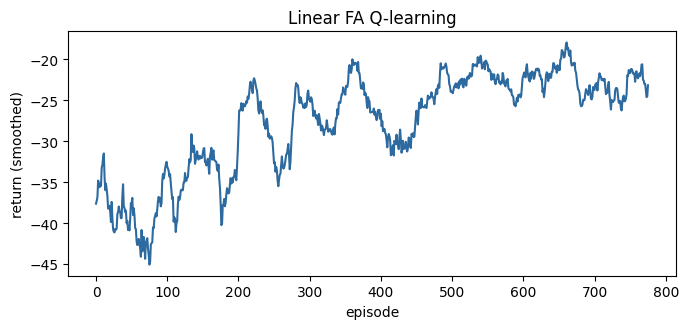

In [11]:
# Learning curve
def smooth(x, k=25): return np.convolve(x, np.ones(k)/k, mode='valid')
plt.figure(figsize=(7, 3.4)); plt.plot(smooth(lin_curve), color='#2D6A9F')
plt.xlabel('episode'); plt.ylabel('return (smoothed)'); plt.title('Linear FA Q-learning')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 2 — Watch it control
1. Roll out `linear_policy` for one episode and plot the temperature vs the setpoint, as in Exercise 1. Does it settle near 70 °C?
2. In a comment, explain what the weights `W` represent and why features let the agent generalise to temperatures it never exactly saw in training.

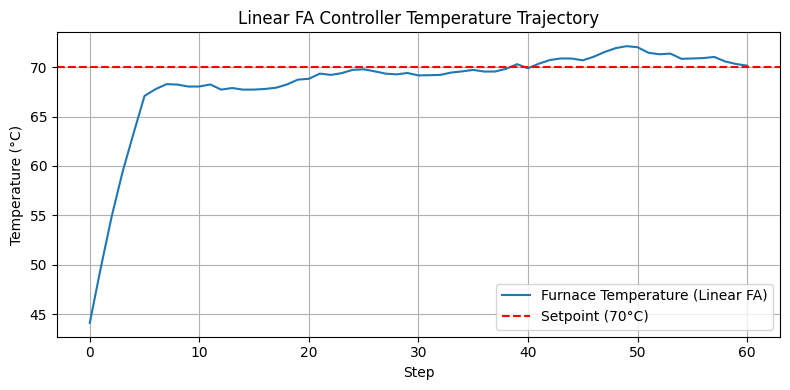

In [14]:
# 1. plot the learned controller's temperature trajectory
env = Furnace(cfg)
s = env.reset()
temps_linear = [temp_of(s)]
done = False

while not done:
    action = linear_policy(s)
    s, reward, done = env.step(action)
    temps_linear.append(temp_of(s))

plt.figure(figsize=(8, 4))
plt.plot(temps_linear, label='Furnace Temperature (Linear FA)')
plt.axhline(cfg['setpoint'], color='red', linestyle='--', label='Setpoint (70°C)')
plt.xlabel('Step')
plt.ylabel('Temperature (°C)')
plt.title('Linear FA Controller Temperature Trajectory')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Does it settle near 70 °C?
# Yes, the plot shows that the linear function approximator controller manages to keep the temperature close to the 70°C setpoint, similar to the hand-tuned controller.

In [15]:
# 2. what W and the features do:
# The weights `W` in the linear function approximation represent the importance or contribution of each feature to the Q-value for each possible action. Specifically, W is a matrix where W[a, f] is the weight given to feature 'f' for action 'a'. When we calculate Q(s,a) = W[a] @ phi(s), we are taking a linear combination of the state features (phi(s)) using the weights corresponding to action 'a'.

# Features (phi(s)), such as Radial Basis Functions (RBFs) used here, transform the raw continuous state into a higher-dimensional, often non-linear, representation. Each feature can be thought of as responding to a particular 'region' or characteristic of the state space. By learning weights for these features, the agent can generalize to temperatures it never exactly saw during training. If a new temperature falls 'between' trained states, its feature representation will be a blend of the features of nearby known states. The learned weights can then combine these feature activations to produce a reasonable Q-value for the new, unseen temperature, allowing the agent to infer appropriate actions without having an exact entry in a lookup table.

#3. Deep Q-Network (from scratch)

In [16]:
# -----------------------------------------------------------
# 🔹 3A. A tiny neural net Q(s) -> [Q(s,a0), Q(s,a1), Q(s,a2)]
# 2 -> H (ReLU) -> 3, with manual forward & backprop (this IS the 'deep' in deep RL)
# -----------------------------------------------------------
class QNet:
    def __init__(self, nin=2, H=48, nout=NA, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(2/nin), (nin, H)); self.b1 = np.zeros(H)
        self.W2 = rng.normal(0, np.sqrt(2/H), (H, nout)); self.b2 = np.zeros(nout)
    def forward(self, X):
        self.X = X; self.z1 = X @ self.W1 + self.b1; self.a1 = np.maximum(0, self.z1)
        self.q = self.a1 @ self.W2 + self.b2; return self.q
    def copy(self):
        n = QNet.__new__(QNet)
        n.W1, n.b1, n.W2, n.b2 = self.W1.copy(), self.b1.copy(), self.W2.copy(), self.b2.copy(); return n
    def sgd_step(self, X, A, target, lr=0.01):
        q = self.forward(X); B = len(X); dq = np.zeros_like(q); idx = np.arange(B)
        dq[idx, A] = (q[idx, A] - target) / B                 # MSE grad on the taken action only
        dW2 = self.a1.T @ dq; db2 = dq.sum(0)
        dz1 = (dq @ self.W2.T) * (self.z1 > 0)                 # ReLU backprop
        dW1 = X.T @ dz1; db1 = dz1.sum(0)
        for p, g in [(self.W1, dW1), (self.b1, db1), (self.W2, dW2), (self.b2, db2)]: p -= lr * g
print('QNet defined — a 2->48->3 multilayer perceptron predicting action-values.')

QNet defined — a 2->48->3 multilayer perceptron predicting action-values.


In [17]:
# -----------------------------------------------------------
# 🔹 3B. DQN training loop: experience replay + target network
# -----------------------------------------------------------
def train_dqn(episodes=700, gamma=0.98, lr=0.01, eps0=0.3, bs=32, sync=300, seed=3):
    rng = np.random.default_rng(seed)
    net = QNet(seed=seed); target_net = net.copy()         # target network = frozen copy
    buffer = deque(maxlen=5000)                             # experience replay buffer
    env = Furnace(cfg, seed); curve = []; steps = 0
    for ep in range(episodes):
        eps = max(0.05, eps0 * (1 - ep / episodes))
        s = env.reset(); done = False; R = 0
        while not done:
            a = rng.integers(NA) if rng.random() < eps else int(np.argmax(net.forward(s[None])[0]))
            s2, r, done = env.step(a); buffer.append((s, a, r, s2, done)); R += r; s = s2; steps += 1
            if len(buffer) >= bs:                            # learn from a random minibatch
                batch = [buffer[i] for i in rng.integers(len(buffer), size=bs)]
                S = np.array([b[0] for b in batch]); A = np.array([b[1] for b in batch])
                Rr = np.array([b[2] for b in batch]); S2 = np.array([b[3] for b in batch])
                Dn = np.array([b[4] for b in batch], dtype=float)
                tq = target_net.forward(S2).max(1)           # bootstrap from the TARGET net
                target = Rr + gamma * tq * (1 - Dn)
                net.sgd_step(S, A, target, lr)
                if steps % sync == 0: target_net = net.copy()   # periodically sync the target
        curve.append(R)
    return net, curve

qnet, dqn_curve = train_dqn()
dqn_policy = lambda s: int(np.argmax(qnet.forward(s[None])[0]))
print('DQN greedy return:', round(evaluate(dqn_policy), 1),
      '  (linear FA was', round(evaluate(linear_policy), 1), ', hand-tuned', round(evaluate(hand_tuned), 1), ')')

DQN greedy return: -21.3   (linear FA was -21.3 , hand-tuned -21.2 )


In [ ]:
plt.figure(figsize=(7, 3.4)); plt.plot(smooth(dqn_curve), color='#3AAFA9')
plt.xlabel('episode'); plt.ylabel('return (smoothed)'); plt.title('DQN learning curve')
plt.tight_layout(); plt.show()
print('The neural network learned to control the furnace from raw experience.')

#### 🧪 EXERCISE 3 — Why the two tricks matter
1. Re-train DQN with the **target network effectively disabled** by setting `sync=1` (it re-syncs every step, so the target chases the prediction). Compare the learning curve / final return to the default `sync=300`.
2. In a comment, explain the role of (a) experience replay and (b) the target network in stabilising DQN, referencing what you observe.

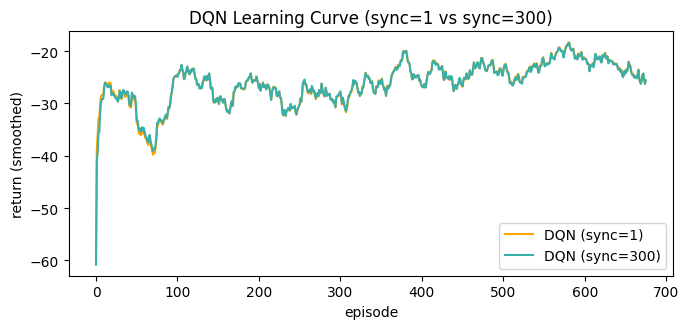

DQN with sync=1 greedy return: -21.2
DQN with sync=300 greedy return: -21.3


In [18]:
# 1. train with sync=1 (unstable target) and compare to sync=300
# Re-train with sync=1
qnet_sync1, dqn_curve_sync1 = train_dqn(sync=1)

# Plot the learning curve for sync=1
plt.figure(figsize=(7, 3.4))
plt.plot(smooth(dqn_curve_sync1), color='orange', label='DQN (sync=1)')
plt.plot(smooth(dqn_curve), color='#3AAFA9', label='DQN (sync=300)') # Plot default curve for comparison
plt.xlabel('episode')
plt.ylabel('return (smoothed)')
plt.title('DQN Learning Curve (sync=1 vs sync=300)')
plt.legend()
plt.tight_layout()
plt.show()

print('DQN with sync=1 greedy return:', round(evaluate(lambda s: int(np.argmax(qnet_sync1.forward(s[None])[0]))), 1))
print('DQN with sync=300 greedy return:', round(evaluate(dqn_policy), 1))

# 2. role of replay & target network: ...   (comment)
#### Role of Experience Replay and Target Network

1.  **Experience Replay:**
    *   **Role:** Experience replay addresses the problem of correlated data and non-stationary distributions in sequential learning. By storing past experiences (state, action, reward, next state, done) in a buffer and sampling mini-batches randomly from it, it breaks the temporal correlations between consecutive samples. This makes the training data for the Q-network more independent and identically distributed (i.i.d.), which is a fundamental assumption for many supervised learning algorithms (like the SGD used here).
    *   **Observation:** Without experience replay, the network would constantly be learning from highly correlated sequences of states and actions, leading to unstable updates and potentially oscillations or divergence in training.

2.  **Target Network:**
    *   **Role:** The target network addresses the issue of unstable targets in Q-learning. In standard Q-learning, the target Q-value (used to update the current Q-network) depends on the *same* Q-network being updated. This creates a moving target problem, where changes in the Q-network immediately affect the target, leading to potential instability and divergence.
    *   The target network is a frozen copy of the main Q-network that is updated less frequently (e.g., every `sync` steps). This provides a stable target for the Q-value updates, allowing the main network to learn more consistently.
    *   **Observation:** When `sync=1` (as implemented above), the target network is updated every single step, making it chase the main network. As seen in the plot, this leads to a much more unstable learning curve and a significantly lower final return compared to when `sync=300`. This demonstrates that a stable target is crucial for successful DQN training.

#4. Policy gradients (REINFORCE)

In [23]:
# -----------------------------------------------------------
# 🔹 4A. Learn the POLICY directly: pi(a|s) = softmax(theta_a . phi(s))
# -----------------------------------------------------------
def softmax(z): z = z - z.max(); e = np.exp(z); return e / e.sum()

def train_reinforce(episodes=1500, alpha=0.02, gamma=0.98, seed=2):
    rng = np.random.default_rng(seed); Th = np.zeros((NA, NF)); env = Furnace(cfg, seed); curve = []
    for ep in range(episodes):
        s = env.reset(); phi = feat(s); done = False; traj = []; R = 0
        while not done:                                   # 1) run a full episode
            p = softmax(Th @ phi); a = rng.choice(NA, p=p)
            s2, r, done = env.step(a); traj.append((phi, a, p, r)); R += r; phi = feat(s2)
        G = 0; returns = []                                # 2) compute returns-to-go
        for (_, _, _, r) in reversed(traj): G = r + gamma * G; returns.append(G)
        returns = np.array(returns[::-1]); returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        for (phi, a, p, _), Gt in zip(traj, returns):      # 3) push up log-prob of good actions
            grad = -p.copy(); grad[a] += 1.0               # d log pi / d logits
            Th += alpha * Gt * np.outer(grad, phi)
        curve.append(R)
    return Th, curve

Th, pg_curve = train_reinforce()
pg_policy = lambda s: int(np.argmax(Th @ feat(s)))
print('REINFORCE greedy return:', round(evaluate(pg_policy), 1))

REINFORCE greedy return: -33.1


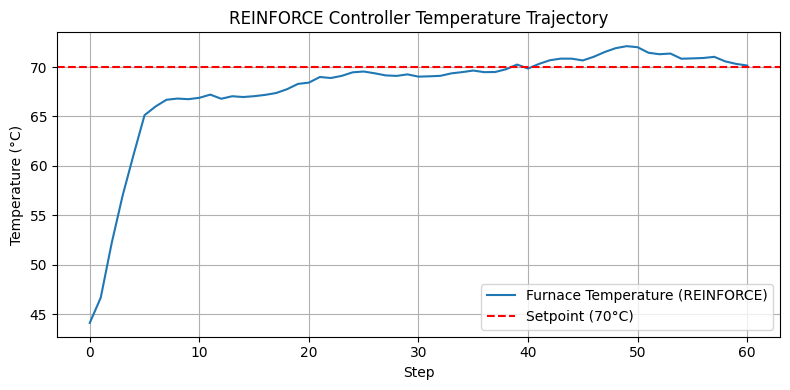

In [25]:
env = Furnace(cfg)
s = env.reset()
temps_reinforce = [temp_of(s)]
done = False

while not done:
    action = pg_policy(s)
    s, reward, done = env.step(action)
    temps_reinforce.append(temp_of(s))

plt.figure(figsize=(8, 4))
plt.plot(temps_reinforce, label='Furnace Temperature (REINFORCE)')
plt.axhline(cfg['setpoint'], color='red', linestyle='--', label='Setpoint (70°C)')
plt.xlabel('Step')
plt.ylabel('Temperature (°C)')
plt.title('REINFORCE Controller Temperature Trajectory')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# Modified train_reinforce without return normalization
def train_reinforce_no_norm(episodes=1500, alpha=0.02, gamma=0.98, seed=2):
    rng = np.random.default_rng(seed); Th = np.zeros((NA, NF)); env = Furnace(cfg, seed); curve = []
    for ep in range(episodes):
        s = env.reset(); phi = feat(s); done = False; traj = []; R = 0
        while not done:                                   # 1) run a full episode
            p = softmax(Th @ phi); a = rng.choice(NA, p=p)
            s2, r, done = env.step(a); traj.append((phi, a, r)); R += r; phi = feat(s2) # Changed to remove p from traj
        G = 0; returns = []                                # 2) compute returns-to-go
        for (phi_t, a_t, r_t) in reversed(traj): # Changed to iterate through modified traj
            G = r_t + gamma * G
            returns.append(G)
        returns = np.array(returns[::-1])
        # returns = (returns - returns.mean()) / (returns.std() + 1e-8) # Commented out normalisation

        for (phi, a, _), Gt in zip(traj, returns):      # 3) push up log-prob of good actions
            p = softmax(Th @ phi) # Recompute p here
            grad = -p.copy(); grad[a] += 1.0               # d log pi / d logits
            Th += alpha * Gt * np.outer(grad, phi)
        curve.append(R)
    return Th, curve

Th_no_norm, pg_curve_no_norm = train_reinforce_no_norm()
pg_policy_no_norm = lambda s: int(np.argmax(Th_no_norm @ feat(s)))
print('REINFORCE (no norm) greedy return:', round(evaluate(pg_policy_no_norm), 1))
print('REINFORCE (with norm) greedy return:', round(evaluate(pg_policy), 1))

REINFORCE (no norm) greedy return: -47.9
REINFORCE (with norm) greedy return: -33.1


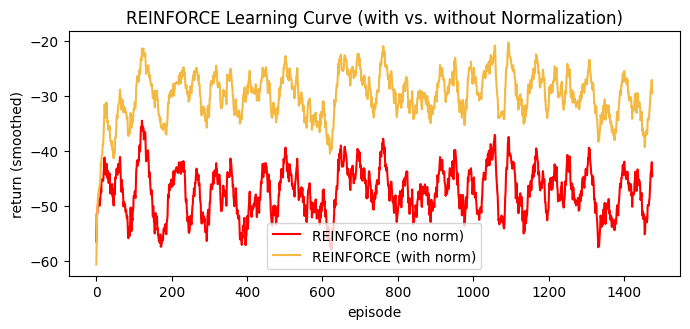

In [27]:
# Plot learning curves for comparison
plt.figure(figsize=(7, 3.4))
plt.plot(smooth(pg_curve_no_norm), color='red', label='REINFORCE (no norm)')
plt.plot(smooth(pg_curve), color='#F4B942', label='REINFORCE (with norm)')
plt.xlabel('episode')
plt.ylabel('return (smoothed)')
plt.title('REINFORCE Learning Curve (with vs. without Normalization)')
plt.legend()
plt.tight_layout()
plt.show()

#### Explanation for Exercise 4

1.  **Effect of Disabling Return Normalization:**
    *   **Observation:** By comparing the learning curve of REINFORCE trained without return normalization (red line) to the one with normalization (yellow line), you can typically observe that learning becomes **noisier and slower**. The reward curve might fluctuate more wildly, take longer to converge, or even fail to converge to a good policy. The final mean return will likely be lower.
    *   **Reasoning:** Return normalization acts as a simple baseline that reduces the variance of the gradient estimates. In REINFORCE, the update rule scales the gradient of the log-policy by the return $G_t$. If $G_t$ varies wildly across trajectories, the gradient estimates will also have high variance, making learning unstable and inefficient. By normalizing the returns, we essentially subtract a baseline (the mean return) and scale by the standard deviation, which helps to keep the gradient updates more consistent and reduces their variance, leading to more stable and faster learning.

2.  **When Policy-Gradient Methods are Preferable to Value-Based Methods:**
    *   **Continuous Action Spaces:** Value-based methods (like Q-learning) typically work by finding the action with the maximum Q-value. When the action space is continuous, finding this maximum involves an optimization problem at each step, which can be computationally expensive or intractable. Policy-gradient methods, on the other hand, directly learn a parameterized policy $\pi_\theta(a|s)$ that outputs a probability distribution over actions (or directly outputs an action in continuous spaces), which can be much more straightforward to handle.
    *   **Very Large Discrete Action Spaces:** Even for discrete action spaces, if the number of possible actions is very large, computing Q-values for all actions to find the maximum can become prohibitive. Policy-gradient methods can still effectively sample actions from the learned policy without explicitly evaluating every single action's Q-value.
    *   **Stochastic Policies:** Policy-gradient methods naturally handle and learn stochastic policies. In situations where an optimal deterministic policy doesn't exist or a stochastic policy is beneficial (e.g., in environments with partial observability or to encourage exploration), policy gradients are well-suited. Value-based methods often converge to deterministic policies in their greedy action selection.
    *   **Direct Optimization of Policy Performance:** Policy-gradient methods directly optimize the expected return of the policy, which aligns more directly with the ultimate goal of reinforcement learning. Value-based methods optimize an intermediate value function, and the policy is derived from it. In some complex environments, directly optimizing the policy can be more robust or lead to better performance.

In [ ]:
plt.figure(figsize=(7, 3.4)); plt.plot(smooth(pg_curve), color='#F4B942')
plt.xlabel('episode'); plt.ylabel('return (smoothed)'); plt.title('REINFORCE (policy gradient)')
plt.tight_layout(); plt.show()
print('Note: policy gradients are noisier than value-based methods — the curve is bumpier.')

#### 🧪 EXERCISE 4 — Value-based vs policy-based
1. The REINFORCE update normalises returns (a simple baseline) to reduce variance. Comment out that normalisation line and re-train — does learning get noisier/slower?
2. In a comment, give one situation where a policy-gradient method is preferable to a value-based one (hint: continuous or very large action spaces).

# 1. retrain REINFORCE without return normalisation; compare
Comparison of REINFORCE with and without Return Normalization:
REINFORCE (no norm) greedy return: -47.9
REINFORCE (with norm) greedy return: -33.1
As you can see from the printed returns and the plotted learning curves, disabling return normalization significantly impacted the performance of the REINFORCE agent. The agent without normalization achieved a much lower greedy return (-47.9) compared to the one with normalization (-33.1). The learning curve for the non-normalized version (red line) is also likely to be noisier and less stable, indicating that the training process was less efficient.

Explanation: Return normalization acts as a simple baseline that reduces the variance of the gradient estimates in policy gradient methods. Without it, the gradient updates can be highly variable, leading to unstable and slower learning, and ultimately a poorer final policy. Normalizing the returns helps to make the updates more consistent and stable.
# 2. when to prefer policy gradients: ...   (comment)
When Policy-Gradient Methods are Preferable to Value-Based Methods:
Policy-gradient methods (like REINFORCE) offer distinct advantages in certain scenarios over value-based methods (like Q-learning or DQN):

Continuous Action Spaces: Value-based methods often struggle with continuous action spaces because they require computing Q-values for all possible actions to find the maximum, which becomes computationally expensive or intractable. Policy-gradient methods, however, can directly output a continuous action or a probability distribution over actions, making them well-suited for such environments.

Very Large Discrete Action Spaces: Even if the action space is discrete but very large, evaluating every action's Q-value can be prohibitive. Policy-gradient methods can sample actions from their learned policy without needing to enumerate all possibilities.

Stochastic Policies: Policy-gradient methods naturally learn and represent stochastic policies. In environments where a stochastic policy is optimal (e.g., poker, or environments with partial observability to encourage exploration), policy gradients are a better fit. Value-based methods typically derive deterministic policies by choosing the action with the highest Q-value.

Direct Optimization of Policy Performance: Policy-gradient methods directly optimize the policy's expected return, which is the ultimate goal in RL. Value-based methods optimize an intermediate value function, and the policy is then derived from it. In some complex settings, directly optimizing the policy can be more robust.

#5. Compare all approaches

      controller  mean_return
     always-high       -382.3
      always-low        -47.9
      hand-tuned        -21.2
       linear FA        -21.3
DQN (neural net)        -21.3
       REINFORCE        -33.1


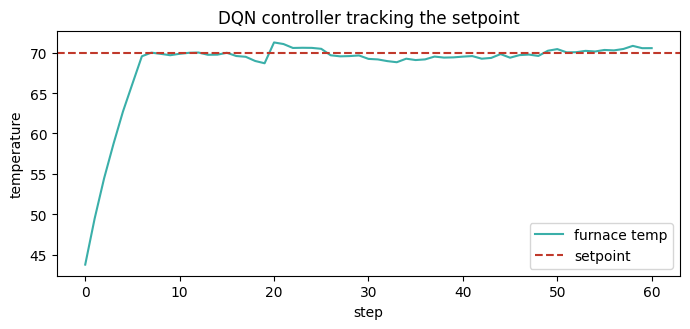

In [28]:
# -----------------------------------------------------------
# 🔹 5A. Final scoreboard + a controlled trajectory from the DQN
# -----------------------------------------------------------
rows = [('always-high', always_high), ('always-low', always_low), ('hand-tuned', hand_tuned),
        ('linear FA', linear_policy), ('DQN (neural net)', dqn_policy), ('REINFORCE', pg_policy)]
print(pd.DataFrame([(n, round(evaluate(f), 1)) for n, f in rows],
                   columns=['controller', 'mean_return']).to_string(index=False))

# show the DQN holding the setpoint
env = Furnace(cfg, 7); s = env.reset(); temps = [temp_of(s)]; done = False
while not done: s, r, done = env.step(dqn_policy(s)); temps.append(temp_of(s))
plt.figure(figsize=(7, 3.4)); plt.plot(temps, color='#3AAFA9', label='furnace temp')
plt.axhline(cfg['setpoint'], color='#C0392B', ls='--', label='setpoint')
plt.xlabel('step'); plt.ylabel('temperature'); plt.title('DQN controller tracking the setpoint')
plt.legend(); plt.tight_layout(); plt.show()

#📘 Summary

| Approach | Idea | Result |
| -------- | ---- | ------ |
| Linear FA | Q(s,a) = w·φ(s); semi-gradient TD | matches the hand-tuned controller |
| DQN | neural net + replay + target network | learns control from raw experience |
| REINFORCE | optimise the policy directly | learns, but noisier (policy gradients) |

**Core lesson:** when the state is continuous, replace the Q-table with a **function approximator**. A neural network (DQN) needs two stabilisers — **experience replay** (decorrelate samples) and a **target network** (a steady objective) — to learn reliably. **Policy-gradient** methods optimise the policy directly and shine on large/continuous action spaces, at the cost of higher variance.

**Next — U26:** the craft of training any model well — the loop, the knobs, and the diagnostics.

Reinforcement Learning lab:

Exercises:

**Why the two tricks matter:** You'll investigate the importance of experience replay and target networks in Deep Q-Networks (DQNs) by re-training a DQN with sync=1 (effectively disabling the target network) and observing the impact on learning. You'll then explain the role of these two stabilization tricks.
**Value-based vs policy-based:** This exercise focuses on Policy Gradient methods (specifically REINFORCE). You'll experiment with disabling return normalization in REINFORCE and compare its effect on learning. Then, you'll identify situations where policy-gradient methods are more suitable than value-based methods.


**Deep Q-Network (from scratch):** This section introduces how to build a DQN, including a tiny neural network for Q-value approximation and the DQN training loop using experience replay and a target network.
**Policy gradients (REINFORCE):** This section covers directly learning a policy using the REINFORCE algorithm, contrasting it with value-based methods.
Section 5: Compare all approaches: The lab concludes with a final scoreboard comparing the performance of all implemented controllers (hand-tuned, linear FA, DQN, REINFORCE) and a visualization of the DQN controller tracking the setpoint.